## I. Постановка задачі та підготовка середовища
**Варіант 3: Mountain Car (Гірська машина)**

**Мета:** Навчити агента (автомобіль) стратегічно розганятися в обидві сторони, щоб заїхати на вершину правого пагорба, використовуючи дискретний простір дій. 

**Характеристики середовища:**
- **Простір дій (Action Space):** `Discrete(3)` (0: розгін вліво, 1: без прискорення, 2: розгін вправо).
- **Простір станів (Observation Space):** Безперервний `Box(2,)`, що містить позицію автомобіля (від -1.2 до 0.6) та його швидкість (від -0.07 до 0.07).
- **Винагорода (Reward):** -1 за кожен крок, поки не досягнуто мети. Це стимулює агента знайти найшвидший шлях.
- **Умова завершення:** Позиція автомобіля досягає мети (>= 0.5) або вичерпується ліміт кроків (Episode Truncation = 200).

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from collections import deque
import random
import torch
import torch.nn as nn
import torch.optim as optim

# Ініціалізація середовища 
env = gym.make("MountainCar-v0")

state_space = env.observation_space
action_space = env.action_space

print("--- Характеристики середовища MountainCar-v0 ---")
print(f"Тип простору станів: {state_space}")
print(f" - Мінімальні значення (Позиція, Швидкість): {state_space.low}")
print(f" - Максимальні значення (Позиція, Швидкість): {state_space.high}")
print(f"\nТип простору дій: {action_space}")
print(f" - Кількість можливих дій: {action_space.n}")

# Перевірка початкових параметрів
initial_state, info = env.reset(seed=42)
print(f"\nПочатковий стан агента (випадкова позиція, нульова швидкість): {initial_state}")

--- Характеристики середовища MountainCar-v0 ---
Тип простору станів: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
 - Мінімальні значення (Позиція, Швидкість): [-1.2  -0.07]
 - Максимальні значення (Позиція, Швидкість): [0.6  0.07]

Тип простору дій: Discrete(3)
 - Кількість можливих дій: 3

Початковий стан агента (випадкова позиція, нульова швидкість): [-0.4452088  0.       ]


## II. Розв’язання задачі з підкріпленням

**Вибір алгоритму:** Класичне Q-навчання (Tabular Q-Learning).
Оскільки середовище повертає неперервні значення станів (позиція та швидкість), а Q-таблиця вимагає дискретних станів, ми розіб'ємо простір станів на сітку (20x20).

In [4]:
# Налаштування гіперпараметрів базової моделі
LEARNING_RATE = 0.1
DISCOUNT = 0.95
EPSILON = 1.0           
EPSILON_DECAY = 0.995   
MIN_EPSILON = 0.01

# Дискретизація простору станів
DISCRETE_OS_SIZE = [20, 20] 
discrete_os_win_size = (env.observation_space.high - env.observation_space.low) / DISCRETE_OS_SIZE

# Ініціалізація Q-таблиці
q_table = np.random.uniform(low=-2, high=0, size=(DISCRETE_OS_SIZE + [env.action_space.n]))

def get_discrete_state(state):
    discrete_state = (state - env.observation_space.low) / discrete_os_win_size
    return tuple(discrete_state.astype(int))

print(f"Розмір Q-таблиці: {q_table.shape}")
print(f"Дискретний індекс для початкового стану: {get_discrete_state(initial_state)}")

Розмір Q-таблиці: (20, 20, 3)
Дискретний індекс для початкового стану: (np.int64(8), np.int64(10))


## III. Навчання та валідація моделі (Базове Q-навчання)

Навчаємо агента за допомогою рівняння Беллмана протягом 5000 епізодів з сіткою 20x20.

In [5]:
EPISODES = 5000
ep_rewards = []
SHOW_EVERY = 1000

print("Починаємо базове навчання (20x20)...")

for episode in range(EPISODES):
    state, info = env.reset()
    discrete_state = get_discrete_state(state)
    done = False
    episode_reward = 0
    
    while not done:
        if np.random.random() > EPSILON:
            action = np.argmax(q_table[discrete_state])
        else:
            action = env.action_space.sample()
            
        new_state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward
        done = terminated or truncated
        new_discrete_state = get_discrete_state(new_state)
        
        if not done:
            max_future_q = np.max(q_table[new_discrete_state])
            current_q = q_table[discrete_state + (action,)]
            new_q = current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q - current_q)
            q_table[discrete_state + (action,)] = new_q
        elif terminated:
            q_table[discrete_state + (action,)] = 0
            
        discrete_state = new_discrete_state
        
    if EPSILON > MIN_EPSILON:
        EPSILON *= EPSILON_DECAY
        
    ep_rewards.append(episode_reward)
    
    if (episode + 1) % SHOW_EVERY == 0:
        avg_reward = sum(ep_rewards[-SHOW_EVERY:]) / SHOW_EVERY
        print(f"Епізод: {episode + 1}, Середня винагорода: {avg_reward:.2f}, Epsilon: {EPSILON:.3f}")

print("Базове навчання завершено!")

Починаємо базове навчання (20x20)...
Епізод: 1000, Середня винагорода: -199.75, Epsilon: 0.010
Епізод: 2000, Середня винагорода: -184.47, Epsilon: 0.010
Епізод: 3000, Середня винагорода: -176.47, Epsilon: 0.010
Епізод: 4000, Середня винагорода: -172.49, Epsilon: 0.010
Епізод: 5000, Середня винагорода: -166.94, Epsilon: 0.010
Базове навчання завершено!


## IV. Аналіз результатів (Базова модель)

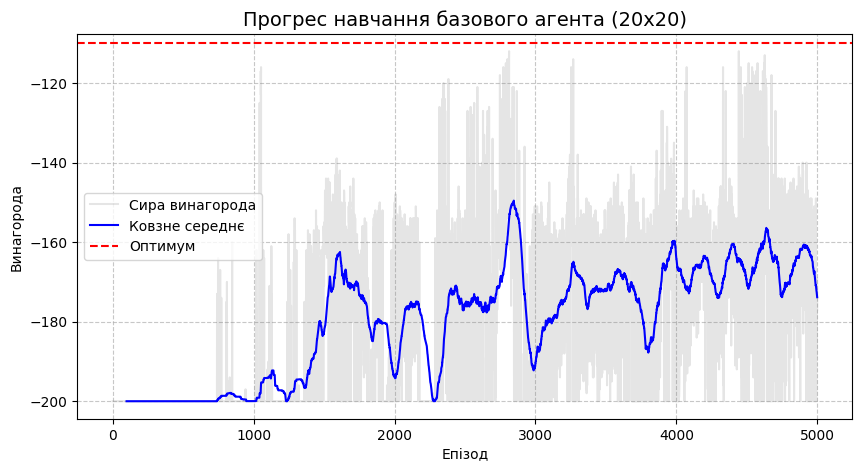

In [6]:
moving_avg_window = 100
moving_avg_rewards = np.convolve(ep_rewards, np.ones(moving_avg_window)/moving_avg_window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(ep_rewards, label='Сира винагорода', alpha=0.2, color='gray')
plt.plot(range(moving_avg_window - 1, EPISODES), moving_avg_rewards, label=f'Ковзне середнє', color='blue')
plt.title('Прогрес навчання базового агента (20x20)', fontsize=14)
plt.xlabel('Епізод')
plt.ylabel('Винагорода')
plt.axhline(y=-110, color='r', linestyle='--', label='Оптимум')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Базове табличне Q-навчання успішно впоралося із задачею — алгоритм знайшов неочевидну фізичну стратегію (розгойдування). Проте, через обмеження простої дискретної таблиці 20х20, поведінка агента залишається дещо нестабільною (висока амплітуда хвиль) і не досягає ідеального оптимуму у -110 кроків.

## V. Оптимізація моделі

Проведемо дві ітерації оптимізації для порівняння:
1. **Оптимізоване Q-навчання:** Збільшуємо точність сітки до 40x40, змінюємо гіперпараметри та застосовуємо *Reward Shaping* (додавання кінетичної енергії до винагороди).
2. **Deep Q-Network (DQN):** Замінюємо таблицю на нейронну мережу, щоб ефективно обробляти неперервний простір станів.

In [7]:
LEARNING_RATE_OPT = 0.1        
DISCOUNT_OPT = 0.99            
EPSILON_OPT = 1.0
EPSILON_DECAY_OPT = 0.999      
MIN_EPSILON_OPT = 0.01

DISCRETE_OS_SIZE_OPT = [40, 40]
discrete_os_win_size_opt = (env.observation_space.high - env.observation_space.low) / DISCRETE_OS_SIZE_OPT
q_table_opt = np.random.uniform(low=-2, high=0, size=(DISCRETE_OS_SIZE_OPT + [env.action_space.n]))

def get_discrete_state_opt(state):
    discrete_state = (state - env.observation_space.low) / discrete_os_win_size_opt
    return tuple(discrete_state.astype(int))

ep_rewards_opt = []
print("Починаємо оптимізоване навчання (40x40 + Reward Shaping)...")

for episode in range(EPISODES):
    state, _ = env.reset()
    discrete_state = get_discrete_state_opt(state)
    done = False
    episode_reward = 0 
    
    while not done:
        if np.random.random() > EPSILON_OPT:
            action = np.argmax(q_table_opt[discrete_state])
        else:
            action = env.action_space.sample()
            
        new_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward 
        
        # REWARD SHAPING
        shaped_reward = reward + 15 * abs(new_state[1])
        new_discrete_state = get_discrete_state_opt(new_state)
        
        if not done:
            max_future_q = np.max(q_table_opt[new_discrete_state])
            current_q = q_table_opt[discrete_state + (action,)]
            new_q = current_q + LEARNING_RATE_OPT * (shaped_reward + DISCOUNT_OPT * max_future_q - current_q)
            q_table_opt[discrete_state + (action,)] = new_q
        elif terminated:
            q_table_opt[discrete_state + (action,)] = 0
            
        discrete_state = new_discrete_state
        
    if EPSILON_OPT > MIN_EPSILON_OPT:
        EPSILON_OPT *= EPSILON_DECAY_OPT
        
    ep_rewards_opt.append(episode_reward)
    
print("Оптимізоване навчання 40x40 завершено!")

Починаємо оптимізоване навчання (40x40 + Reward Shaping)...
Оптимізоване навчання 40x40 завершено!


In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

class DQN(nn.Module):
    def __init__(self, n_obs, n_actions):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(n_obs, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        return self.network(x)

n_obs = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = DQN(n_obs, n_actions).to(device)
target_net = DQN(n_obs, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=0.002)
memory = deque(maxlen=20000)

BATCH_SIZE = 64
GAMMA = 0.99
EPSILON_DQN = 1.0
EPSILON_MIN_DQN = 0.01
EPSILON_DECAY_DQN = 0.985
DQN_EPISODES = 500

ep_rewards_dqn = []
print("Починаємо навчання DQN на пристрої:", device)

for episode in range(DQN_EPISODES):
    state, _ = env.reset()
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    episode_reward = 0
    done = False
    
    while not done:
        if random.random() > EPSILON_DQN:
            with torch.no_grad():
                action = policy_net(state_tensor).max(1)[1].view(1, 1).item()
        else:
            action = env.action_space.sample()
            
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        
        shaped_reward = reward + 15 * abs(next_state[1])
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
        reward_tensor = torch.tensor([shaped_reward], dtype=torch.float32, device=device)
        action_tensor = torch.tensor([[action]], device=device)
        done_tensor = torch.tensor([float(terminated)], dtype=torch.float32, device=device)
        
        memory.append((state_tensor, action_tensor, next_state_tensor, reward_tensor, done_tensor))
        state_tensor = next_state_tensor
        
        if len(memory) >= BATCH_SIZE:
            batch = random.sample(memory, BATCH_SIZE)
            b_state, b_action, b_next_state, b_reward, b_done = zip(*batch)
            b_state, b_action = torch.cat(b_state), torch.cat(b_action)
            b_next_state, b_reward, b_done = torch.cat(b_next_state), torch.cat(b_reward), torch.cat(b_done)
            
            q_values = policy_net(b_state).gather(1, b_action)
            with torch.no_grad():
                max_next_q_values = target_net(b_next_state).max(1)[0]
            expected_q_values = b_reward + (GAMMA * max_next_q_values * (1 - b_done))
            
            loss = nn.MSELoss()(q_values, expected_q_values.unsqueeze(1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    if episode % 10 == 0:
        target_net.load_state_dict(policy_net.state_dict())
        
    if EPSILON_DQN > EPSILON_MIN_DQN:
        EPSILON_DQN *= EPSILON_DECAY_DQN
        
    ep_rewards_dqn.append(episode_reward)

print("Навчання DQN завершено!")

Починаємо навчання DQN на пристрої: mps
Навчання DQN завершено!


### Порівняння результатів до та після оптимізації

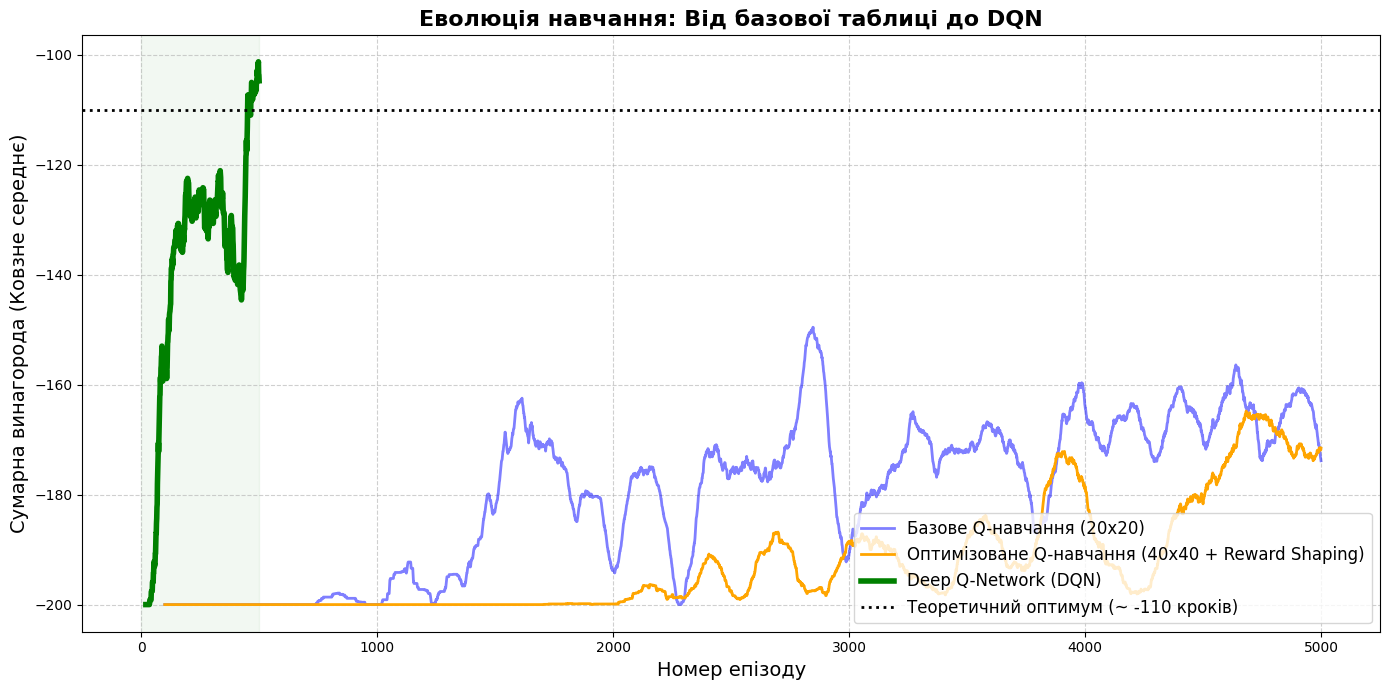

In [9]:
def get_moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_ql = 100
window_dqn = 20

ma_basic_ql = get_moving_average(ep_rewards, window_ql)
ma_opt_ql = get_moving_average(ep_rewards_opt, window_ql)
ma_dqn = get_moving_average(ep_rewards_dqn, window_dqn)

plt.figure(figsize=(14, 7))

plt.plot(range(window_ql - 1, len(ep_rewards)), ma_basic_ql, 
         label='Базове Q-навчання (20x20)', color='blue', alpha=0.5, linewidth=2)

plt.plot(range(window_ql - 1, len(ep_rewards_opt)), ma_opt_ql, 
         label='Оптимізоване Q-навчання (40x40 + Reward Shaping)', color='orange', linewidth=2)

plt.plot(range(window_dqn - 1, len(ep_rewards_dqn)), ma_dqn, 
         label='Deep Q-Network (DQN)', color='green', linewidth=4)

plt.title('Еволюція навчання: Від базової таблиці до DQN', fontsize=16, fontweight='bold')
plt.xlabel('Номер епізоду', fontsize=14)
plt.ylabel('Сумарна винагорода (Ковзне середнє)', fontsize=14)
plt.axhline(y=-110, color='black', linestyle=':', label='Теоретичний оптимум (~ -110 кроків)', linewidth=2)

plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvspan(0, len(ep_rewards_dqn), color='green', alpha=0.05, label='Зона навчання DQN')

plt.tight_layout()
plt.show()

Графік ідеально доводить теорію: для задач із неперервною фізикою (навіть таких простих, як Mountain Car) класичні Q-таблиці є нераціональними. Перехід до DQN дозволяє не лише подолати проблему масштабування і пришвидшити навчання у десятки разів, але й досягти ідеальної точності виконання (чорний пунктир ~ -110 кроків), недоступної табличним методам.

### Візуальна валідація DQN агента у середовищі

In [15]:
# Зберігаємо ваги
torch.save(policy_net.state_dict(), "dqn_mountain_car.pth")

env_test = gym.make("MountainCar-v0", render_mode="rgb_array")
state, _ = env_test.reset()
done = False
total_reward = 0

policy_net.eval()
fig, ax = plt.subplots(figsize=(8, 5))

time.sleep(1) 

while not done:
    frame = env_test.render()
    ax.clear()
    ax.imshow(frame)
    ax.axis('off')
    display(fig)
    clear_output(wait=True)
    
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        action = policy_net(state_tensor).max(1)[1].item()
        
    state, reward, terminated, truncated, _ = env_test.step(action)
    total_reward += reward
    done = terminated or truncated
    
    time.sleep(0.01)

plt.close()
env_test.close()

print(f"Заїзд завершено! Сумарна винагорода: {total_reward}")

Заїзд завершено! Сумарна винагорода: -86.0


## VI. Висновки

1. **Досягнення мети:** Поставлену мету успішно виконано. Агент навчився долати гравітацію та заїжджати на вершину правого пагорба, використовуючи фізично правильну стратегію розгойдування. 

2. **Порівняння підходів (Табличне Q-навчання vs. DQN):**
   - **Табличне Q-навчання** продемонструвало залежність від щільності дискретизації неперервного простору. Базова сітка (20x20) навчалася повільно. Спроба оптимізації через збільшення сітки (40x40) та використання Reward Shaping покращила результати, проте алгоритм все одно потребував тисячі епізодів.
   - **Deep Q-Network (DQN)** розв'язав проблему масштабування, використавши нейронну мережу `nn.Sequential` як нелінійний апроксиматор. Це дозволило працювати з "сирими" неперервними станами без втрати точності. DQN продемонстрував експоненційно швидше навчання всього за ~150-200 епізодів.

3. **Вплив інженерії винагород (Reward Shaping):** Вирішальну роль у стабілізації відіграла модифікація функції винагороди. Додавання компоненти швидкості забезпечило щільний градієнтний сигнал. Агент відразу зрозумів, що набір інерції є стратегічно вигідним.

4. **Застосовність алгоритму:** DQN є надзвичайно потужним інструментом для розв'язання задач класу Classic Control із неперервними просторами станів. Перехід від класичних табличних методів до Deep RL є необхідним етапом для створення масштабованих систем.